In [1]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
# include(joinpath(functions_directory, "load_model_starting_points_OLD.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected_with_MVP.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))
include(joinpath(functions_directory, "create_vaccine_data_MMR_only.jl"))

create_vaccine_data_MMR_only (generic function with 1 method)

In [2]:
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data_MMR_only()

(["Measles", "Mumps", "Rubella"], ["M", "MR", "MMR"], Dict("MMR" => ["Measles", "Mumps", "Rubella"], "MR" => ["Measles", "Rubella"], "M" => ["Measles"]), ["Biological_E", "GSK", "PT_Bio", "Serum_Institute"], Dict("MMR" => ["Serum_Institute", "GSK"], "MR" => ["Serum_Institute", "Biological_E"], "M" => ["Serum_Institute", "PT_Bio"]), Dict("Measles" => ["MMR", "MR", "M"], "Mumps" => ["MMR"], "Rubella" => ["MMR", "MR"]), Dict("Serum_Institute" => ["MMR", "MR", "M"], "Biological_E" => ["MR"], "GSK" => ["MMR"], "PT_Bio" => ["M"]), Dict("Measles" => ["Serum_Institute", "GSK", "Biological_E", "PT_Bio"], "Mumps" => ["Serum_Institute", "GSK"], "Rubella" => ["Serum_Institute", "GSK", "Biological_E"]), Dict("Serum_Institute" => ["Measles", "Mumps", "Rubella"], "Biological_E" => ["Measles", "Rubella"], "GSK" => ["Measles", "Mumps", "Rubella"], "PT_Bio" => ["Measles"]), Dict("Medium" => ["Sanofi", "Pfizer", "Haffkine_Bio", "Bharat_Biotech", "Merck_Sharp", "PT_Bio", "LG_Chem", "BB_NCIPD"], "Small" =>

In [3]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, 1000, A, V)

(Any[("Measles", 1, 3), ("Mumps", 1, 3), ("Rubella", 1, 3)], Any[("M", 280764.0), ("MR", 879375.0), ("MMR", 83172.0)], Any[("Measles", 0.0), ("Mumps", 0.0), ("Rubella", 0.0)])

In [4]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, beta, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(data_dir, 1000, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Serum_Institute" => 587114.0, "Biological_E" => 164886.0, "GSK" => 226763.0, "PT_Bio" => 45912.0), Dict{Any, Any}(("MMR", "Serum_Institute", 5) => 2.2953333333333332, ("M", "PT_Bio", 5) => 0.2675, ("M", "Serum_Institute", 8) => 0.436734375, ("MR", "Serum_Institute", 5) => 0.890625, ("MR", "Serum_Institute", 10) => 0.89083984375, ("MMR", "GSK", 8) => 4.47, ("MR", "Serum_Institute", 2) => 0.8925000000000001, ("MR", "Biological_E", 3) => 0.87, ("M", "PT_Bio", 4) => 0.265, ("MR", "Biological_E", 8) => 0.92121875…), Dict{Any, Any}(("MMR", 1) => 3.207, ("MMR", 2) => 3.303166666666667, ("MMR", 8) => 3.372729166666667, ("M", 6) => 0.35134375, ("MR", 4) => 0.917875, ("MR", 10) => 0.905447265625, ("M", 8) => 0.35164843749999997, ("MR", 6) => 0.9084062500000001, ("M", 9) => 0.35180078125, ("MMR", 9) => 3.3743854166666667…), Dict{Any, Any}("Serum_Institute" => 1.1832658854166667, "Biological_E" =

In [7]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios = process_scenario_data_n_selected_with_MVP(current_directory, data_dir, 3, 3, A, T, P, 1, 10, 5, 1, 1, 1, 1,  false, 1, 1)

(Dict("Partial_1" => [7], "All" => [8, 1, 29, 35, 9, 7, 14, 6, 5], "Partial_2" => [8, 1, 29, 35, 9, 14, 6, 5]), Dict(5 => 0.025618016356978218, 29 => 0.0001536273958561518, 35 => 0.0007284057562145128, 7 => 0.0018816819956863726, 6 => 0.019499295292086764, 9 => 0.00045823343936403897, 8 => 0.0020084274150849366, 14 => 0.000836891719906036, 1 => 0.9488154206288231), Dict(5 => 0.025666312194530333, 29 => 0.00015391701873914297, 35 => 0.0007297789681597295, 6 => 0.019536055936809783, 9 => 0.0004590973145150299, 8 => 0.0020122137614914074, 14 => 0.0008384694527792637, 1 => 0.9506041553529754), [7], [8, 1, 29, 35, 9, 14, 6, 5], 7, Dict{Any, Any}(("GSK", 2, 5) => 2.26762686e8, ("Biological_E", 1, 14) => 1.6488569e8, ("PT_Bio", 2, 7) => 4.5911731e7, ("Serum_Institute", 10, 29) => 5.87114096e8, ("GSK", 6, 6) => 2.26762686e8, ("Biological_E", 2, 29) => 1.6488569e8, ("Biological_E", 8, 1) => 1.6488569e8, ("Biological_E", 6, 29) => 1.63879088e8, ("PT_Bio", 8, 29) => 4.5911731e7, ("Biological_E", 

In [12]:
d_real_tilde

Dict{Any, Any} with 270 entries:
  ("Rubella", 8, 7)  => 6.70139e8
  ("Mumps", 10, 29)  => 5.22932e7
  ("Mumps", 5, 1)    => 2.35362e7
  ("Mumps", 1, 35)   => 2.29273e7
  ("Mumps", 7, 1)    => 1.86504e7
  ("Rubella", 5, 7)  => 6.19977e8
  ("Measles", 1, 9)  => 5.20689e8
  ("Mumps", 1, 7)    => 2.08051e7
  ("Measles", 5, 29) => 6.10795e8
  ("Measles", 1, 5)  => 4.03209e8
  ("Mumps", 9, 35)   => 5.67765e7
  ("Mumps", 9, 8)    => 5.47033e7
  ("Rubella", 4, 14) => 4.28028e8
  ("Measles", 7, 5)  => 1.16466e9
  ("Mumps", 8, 1)    => 8.9096e6
  ("Measles", 2, 6)  => 3.58617e8
  ("Rubella", 9, 35) => 7.19104e8
  ("Rubella", 6, 8)  => 5.67085e8
  ("Rubella", 7, 29) => 6.25044e8
  ⋮                  => ⋮

In [9]:
total_demand = sum(values(d_real_tilde))
println("Total Demand: $total_demand")

Total Demand: 1.076122072e11


In [5]:
gurobi_solver = JuMP.optimizer_with_attributes(Gurobi.Optimizer, "FeasibilityTol" => 1e-3, "OutputFlag" => 0, "Presolve" => 0, "NumericFocus" => 1, "Heuristics" => 0.5, "PumpPasses" => 10, "GomoryPasses"=>2)
Masterproblem = JuMP.Model()
JuMP.set_optimizer(Masterproblem, gurobi_solver)


 @variable(Masterproblem, 0.0 <= F[a in A, (t, tau) in F_time_set] <= 1.0, Bin)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-04
Set parameter FeasibilityTol to value 0.001


2-dimensional DenseAxisArray{VariableRef,2,...} with index sets:
    Dimension 1, ["Measles", "Mumps", "Rubella"]
    Dimension 2, Any[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6)  …  (7, 7), (7, 8), (7, 9), (7, 10), (8, 8), (8, 9), (8, 10), (9, 9), (9, 10), (10, 10)]
And data, a 3×40 Matrix{VariableRef}:
 F[Measles,(1, 1)]  F[Measles,(1, 2)]  …  F[Measles,(10, 10)]
 F[Mumps,(1, 1)]    F[Mumps,(1, 2)]       F[Mumps,(10, 10)]
 F[Rubella,(1, 1)]  F[Rubella,(1, 2)]     F[Rubella,(10, 10)]

In [6]:
num_vars = JuMP.num_variables(Masterproblem)


120

In [ ]:
d_real_tilde[("Rubella",1,1)]

In [1]:
# single cut
new_updated_data = {"lb":[-6.470189452911742e11,-6.446875599759008e11,-6.407525194400902e11],"ub":[-2.666853048510484e11,-5.483764944644929e11,-5.483764944644929e11]}

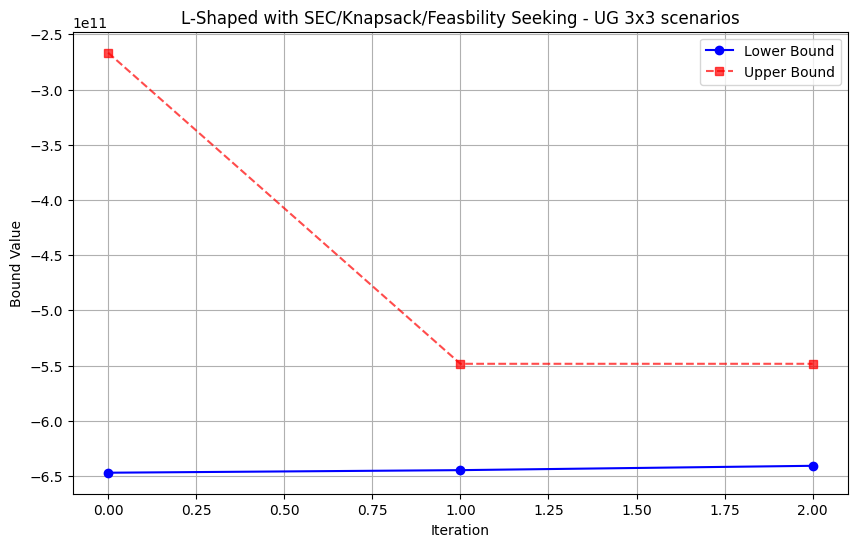

In [2]:
import matplotlib.pyplot as plt

# # Adjust the length of both lists to match the shorter one
# min_length = min(len(lower_bounds), len(upper_bounds))

# # Trim both lists to the same length
# lower_bounds = lower_bounds[:min_length]
# upper_bounds = upper_bounds[:min_length]
# iterations = list(range(min_length))

# Plot the adjusted lower and upper bounds
plt.figure(figsize=(10, 6))
# Plot lower and upper bounds
plt.plot(new_updated_data["lb"], label="Lower Bound", marker="o", linestyle="-", color="blue")
plt.plot(new_updated_data["ub"], label="Upper Bound", marker="s", linestyle="--", color="red", alpha=0.7)

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Bound Value")
plt.title("L-Shaped with SEC/Knapsack/Feasbility Seeking - UG 3x3 scenarios")
plt.legend()
plt.grid(True)
# plt.savefig("UG_L_shaped_SEC_Knapsack_feas_3x3_1.pdf")
# Show the plot
plt.show()


In [ ]:
            if iter2 >= 2
                println("Generating trust region cuts")
                # F variable
                try
                    unregister(Masterproblem, :trust_region_constr_all)
                catch e
                    println("No constraint: ", e)
                finally
                    trust_expr_F = sum(
                        F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
                                                  Masterproblem[:F][a, (t, tau)]
                        for a in A, (t, tau) in F_time_set
                    )

                    trust_expr_Y = sum(
                            Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
                            for p in P, t in T
                        )

                    trust_expr_L = sum(
                        L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
                        for p in P, t in T
                    )

                    trust_expr_Z = sum(
                            Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
                            for v in V, p in P_v[v], t in T, m in keys(m_segments)
                        )

                    trust_expr_all = trust_expr_F + trust_expr_Y + trust_expr_L + trust_expr_Z
                    @constraint(Masterproblem, trust_region_constr_all, trust_expr_all <= trust_delta_F)
                end
            end

In [ ]:
                function stringify_full_constraint(con::JuMP.ConstraintRef)
                    obj = JuMP.constraint_object(con)
                    expr = obj.func
                
                    terms = [ "$(coeff) * $(name(var))" for (var, coeff) in expr.terms ]
                    expr_str = join(terms, " + ")
                    expr_str *= expr.constant != 0.0 ? " + $(expr.constant)" : ""
                
                    return expr_str

                end

                function safe_parse_json(path)
                    if isfile(path)
                        content = read(path, String)
                        return isempty(strip(content)) ? Dict{String, String}() : JSON.parse(content)
                    else
                        return Dict{String, String}()
                    end
                end
                

                F_dir = joinpath(results_dir, "F_constraint_check")
                source = string(F_dir, "/", model, "_F_SEC_CUT.json")
                constraint_dict = Dict()
                con_str = []
                
                if iter1 >= 2
                    println("Generating solution elimination constraint for F[a,(t,tau)]")        
                    mismatch_sum = sum(1 - Masterproblem[:F][a, (t, tau)] for a in A, (t, tau) in F_time_set if F_bar[a, (t, tau)] == 1) +
                                   sum(Masterproblem[:F][a, (t, tau)] for a in A, (t, tau) in F_time_set if F_bar[a, (t, tau)] == 0)
                
                    sol_elim = @constraint(Masterproblem, mismatch_sum >= 1)
                    con_str = stringify_full_constraint(sol_elim)
                end
                constraint_dict[string(iter1)] = con_str  # keys must be String for JSON
                # Save updated dict back to file
                open(source, "w") do f
                    JSON.print(f, constraint_dict)
                end

In [ ]:
            # # add solution elimination constraints (Masterproblem, iter, Z_M, Z_M_prev) - create a function for this - MULTIPLE TRUST REGIONS FOR EACH BINARY
            # if iter2 == 1
            #     trust_delta_F = max_horizon_length * max_tender_length * length(A)/ 2
            #     trust_delta_Y = length(P) * length(T) / 2
            #     trust_delta_L = length(P) * length(T) / 2
            #     trust_delta_Z = length(V) * length(P) * length(T) * length(m_segments) /2
            # elseif iter2 >= 2
            #     if Z_M >= Z_M_prev
            #         trust_delta_F = ceil(1.3*trust_delta_F)
            #         trust_delta_Y = ceil(1.3*trust_delta_Y)
            #         trust_delta_L = ceil(1.3*trust_delta_L)
            #         trust_delta_Z = ceil(1.3*trust_delta_Z)
            #     else
            #         trust_delta_F = ceil(0.6*trust_delta_F)
            #         trust_delta_Y = ceil(0.6*trust_delta_Y)
            #         trust_delta_L = ceil(0.6*trust_delta_L)
            #         trust_delta_Z = ceil(0.6*trust_delta_Z)
            #     end
            # end

            # println("Current F trust region RHS: $trust_delta_F")
            # println("Current Y trust region RHS: $trust_delta_Y")
            # println("Current L trust region RHS: $trust_delta_L")
            # println("Current Z trust region RHS: $trust_delta_Z")

            # if iter2 >= 2
            #     println("Generating trust region cuts")
            #     # F variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_F)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         trust_expr = sum(
            #             F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
            #                                       Masterproblem[:F][a, (t, tau)]
            #             for a in A, (t, tau) in F_time_set
            #         )
            #         @constraint(Masterproblem, trust_region_constr_F, trust_expr <= trust_delta_F)
            #     end

            #     # Y variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Y)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Y,
            #             sum(
            #                 Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
            #                 for p in P, t in T
            #             ) <= trust_delta_Y)
            #     end
                

            #     # L variable

            #     try
            #         unregister(Masterproblem, :trust_region_constr_L)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_L,
            #         sum(
            #             L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
            #             for p in P, t in T
            #         ) <= trust_delta_L)
            #     end
            
            #     # # Z variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Z)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Z,
            #             sum(
            #                 Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
            #                 for v in V, p in P_v[v], t in T, m in keys(m_segments)
            #             ) <= trust_delta_Z)
            #     end
            # end #end iter generation of trust region cuts   